Installing yfinance allows us to retrieve historical market data programically from Yahoo Finance .

In [61]:
!pip install yfinance -q

In [62]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Defining Stocks

In [63]:
tickers = [
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "ITC.NS",
    "SUNPHARMA.NS"
]

company_names = {
    "RELIANCE.NS": "Reliance",
    "TCS.NS": "TCS",
    "HDFCBANK.NS": "HDFC Bank",
    "ITC.NS": "ITC",
    "SUNPHARMA.NS": "Sun Pharma"
}

Downloading the Historical Data

In [64]:
data = yf.download(
    tickers,
    start="2021-01-01",
    end="2026-09-01",
    auto_adjust=True
)

data.head()

[*********************100%***********************]  5 of 5 completed


Price            Close                                                    \
Ticker     HDFCBANK.NS      ITC.NS RELIANCE.NS SUNPHARMA.NS       TCS.NS   
Date                                                                       
2021-01-01  663.905762  159.716599  897.047058   561.122314  2521.074707   
2021-01-04  659.689453  159.380539  898.559082   568.792236  2616.811768   
2021-01-05  664.674316  157.924133  887.388245   567.898132  2662.915527   
2021-01-06  661.809265  153.405624  863.986145   569.639160  2627.185547   
2021-01-07  659.805969  151.463791  862.586975   566.439453  2611.086426   

Price             High                                                    ...  \
Ticker     HDFCBANK.NS      ITC.NS RELIANCE.NS SUNPHARMA.NS       TCS.NS  ...   
Date                                                                      ...   
2021-01-01  672.268328  159.978001  901.334799   564.416114  2531.190861  ...   
2021-01-04  669.938866  161.322375  902.192359   573.544708  2626.540535  ...   
2021-01-05  666.561163  159.268485  895.286758   572.838832  2681.210695  ...   
2021-01-06  670.870655  157.961485  887.343173   574.956317  2680.564378  ...   
2021-01-07  667.423135  155.048733  877.864981   572.180052  2652.455071  ...   

Price             Open                                                    \
Ticker     HDFCBANK.NS      ITC.NS RELIANCE.NS SUNPHARMA.NS       TCS.NS   
Date                                                                       
2021-01-01  670.870681  156.766493  897.272694   557.593243  2479.533905   
2021-01-04  669.938866  159.828652  900.477287   564.651436  2539.799911   
2021-01-05  661.180199  158.671001  888.697112   572.603560  2616.940930   
2021-01-06  668.541243  157.924145  887.298046   568.509846  2668.941568   
2021-01-07  667.376558  153.928444  866.807025   570.344924  2647.418435   

Price           Volume                                              
Ticker     HDFCBANK.NS    ITC.NS RELIANCE.NS SUNPHARMA.NS   TCS.NS  
Date                                                                
2021-01-01     8810938  20279389    10015175      8229768  2681440  
2021-01-04    15740192  27927482    24513534     11329298  5113293  
2021-01-05    14386824  18718244    24123091      7790158  5801309  
2021-01-06    22134050  50957586    46401468      6422080  3726716  
2021-01-07    19894842  36298522    32325918      4555702  3717827  

[5 rows x 25 columns]

Extracting Closing Prices

In [65]:
prices = data["Close"].copy()

prices = prices.rename(columns=company_names)

prices.head()


Ticker,HDFC Bank,ITC,Reliance,Sun Pharma,TCS
Date,,,,,
2021-01-01,663.905762,159.716599,897.047058,561.122314,2521.074707
2021-01-04,659.689453,159.380539,898.559082,568.792236,2616.811768
2021-01-05,664.674316,157.924133,887.388245,567.898132,2662.915527
2021-01-06,661.809265,153.405624,863.986145,569.639160,2627.185547
2021-01-07,659.805969,151.463791,862.586975,566.439453,2611.086426


Understanding the Data set

In [66]:
print("Shape:", prices.shape)

print("\nColumns:")
print(prices.columns)

print("\nDate Range:")
print(prices.index.min(), "to", prices.index.max())

print("\nData Types:")
print(prices.dtypes)

Shape: (1403, 5)

Columns:
Index(['HDFC Bank', 'ITC', 'Reliance', 'Sun Pharma', 'TCS'], dtype='object', name='Ticker')

Date Range:
2021-01-01 00:00:00 to 2026-08-31 00:00:00

Data Types:
Ticker
HDFC Bank     float64
ITC           float64
Reliance      float64
Sun Pharma    float64
TCS           float64
dtype: object


Checking missing values identifies missing values from the Data set

In [67]:
prices.isnull().sum()

,0
Ticker,
HDFC Bank,0
ITC,0
Reliance,0
Sun Pharma,0
TCS,0


Handling missing values

In [68]:
prices = prices.dropna()

print(prices.isnull().sum())
print("\nFinal shape:", prices.shape)

Ticker
HDFC Bank     0
ITC           0
Reliance      0
Sun Pharma    0
TCS           0
dtype: int64

Final shape: (1403, 5)


Summary Statistics

In [69]:
prices.describe()

Ticker,HDFC Bank,ITC,Reliance,Sun Pharma,TCS
count,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000
mean,777.152076,309.695352,1232.040593,1249.261878,3108.045085
std,94.951085,92.679860,175.400971,442.485776,451.132369
min,606.489319,150.492844,831.353882,531.101624,1971.788818
25%,706.786652,220.081299,1109.380859,849.985260,2837.737305
50%,761.000488,320.855988,1219.914795,1122.164917,3064.961426
75%,819.421631,387.654099,1384.399048,1688.497620,3334.250122
max,996.419800,463.949219,1584.971802,2001.099976,4230.709473


Plotting Raw Stock Prices

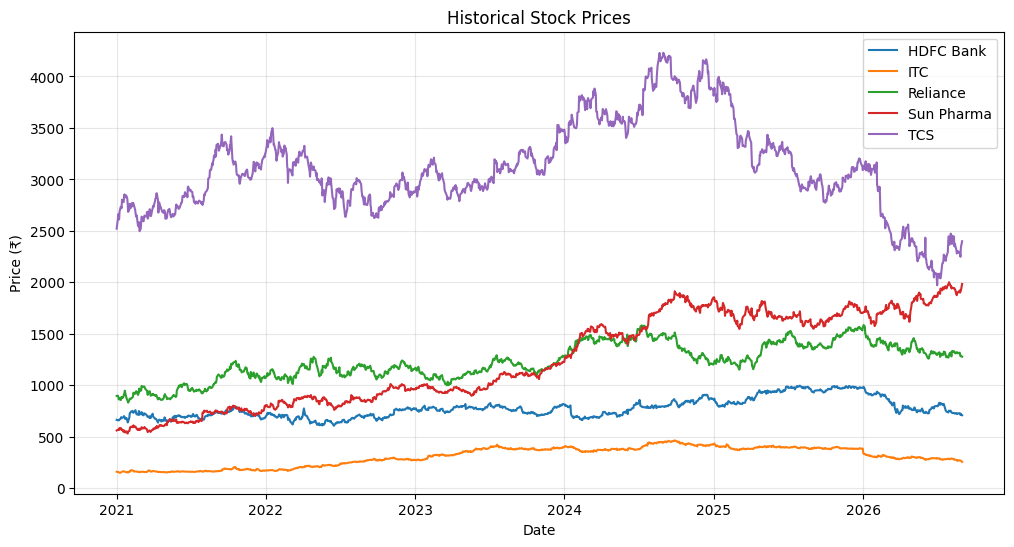

In [70]:
plt.figure(figsize=(12, 6))

for company in prices.columns:
    plt.plot(prices.index, prices[company], label=company)

plt.title("Historical Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Normalizing Stock Prices

In [71]:
normalized_prices = prices / prices.iloc[0] * 100

normalized_prices.head()

Ticker,HDFC Bank,ITC,Reliance,Sun Pharma,TCS
Date,,,,,
2021-01-01,100.000000,100.000000,100.000000,100.000000,100.000000
2021-01-04,99.364924,99.789590,100.168556,101.366889,103.797470
2021-01-05,100.115763,98.877721,98.923266,101.207547,105.626205
2021-01-06,99.684218,96.048642,96.314473,101.517823,104.208953
2021-01-07,99.382474,94.832843,96.158498,100.947590,103.570371


Plotting Normalized Perfomance

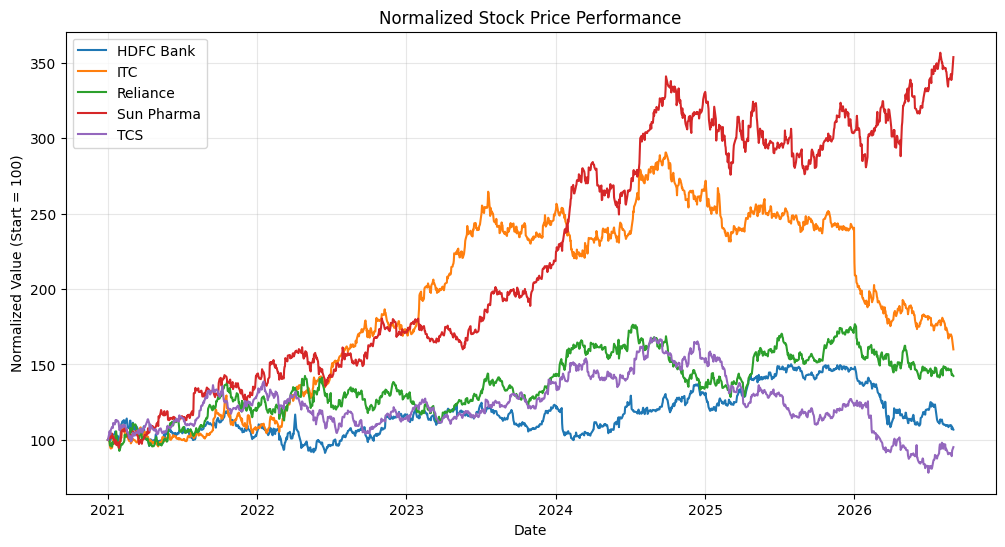

In [72]:
plt.figure(figsize=(12, 6))

for company in normalized_prices.columns:
    plt.plot(
        normalized_prices.index,
        normalized_prices[company],
        label=company
    )

plt.title("Normalized Stock Price Performance")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Start = 100)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Calculating daily returns


In [73]:
daily_returns = prices.pct_change().dropna()

daily_returns.head()

Ticker,HDFC Bank,ITC,Reliance,Sun Pharma,TCS
Date,,,,,
2021-01-04,-0.006351,-0.002104,0.001686,0.013669,0.037975
2021-01-05,0.007556,-0.009138,-0.012432,-0.001572,0.017618
2021-01-06,-0.004310,-0.028612,-0.026372,0.003066,-0.013418
2021-01-07,-0.003027,-0.012658,-0.001619,-0.005617,-0.006128
2021-01-08,0.010874,-0.006410,0.011799,0.031400,0.029049


Inspecting Daily Returns

In [74]:
daily_returns.describe()

Ticker,HDFC Bank,ITC,Reliance,Sun Pharma,TCS
count,1402.000000,1402.000000,1402.000000,1402.000000,1402.000000
mean,0.000140,0.000417,0.000354,0.000988,0.000064
std,0.013636,0.012830,0.014297,0.013182,0.014117
min,-0.084358,-0.097146,-0.074851,-0.045527,-0.083861
25%,-0.006870,-0.006264,-0.008268,-0.006473,-0.007277
50%,0.000015,0.000000,0.000398,0.000625,-0.000195
75%,0.007014,0.007497,0.007936,0.007705,0.007374
max,0.100133,0.068287,0.070192,0.100925,0.066328


Describing annualized returns

In [75]:
trading_days = 252

annualized_returns = daily_returns.mean() * trading_days

annualized_returns

,0
Ticker,
HDFC Bank,0.035227
ITC,0.105193
Reliance,0.089194
Sun Pharma,0.248935
TCS,0.016221


To display the annualized returns in percentages

In [76]:
annualized_returns_percent = annualized_returns * 100

print("Annualized Returns (%)")
print(annualized_returns_percent.round(2))

Annualized Returns (%)
Ticker
HDFC Bank      3.52
ITC           10.52
Reliance       8.92
Sun Pharma    24.89
TCS            1.62
dtype: float64


Calculating Annualized Volatility

In [77]:
annualized_volatility = daily_returns.std() * np.sqrt(trading_days)

annualized_volatility_percent = annualized_volatility * 100

print("Annualized Volatility (%)")
print(annualized_volatility_percent.round(2))

Annualized Volatility (%)
Ticker
HDFC Bank     21.65
ITC           20.37
Reliance      22.70
Sun Pharma    20.93
TCS           22.41
dtype: float64


Return and Risk Table

In [78]:
stock_summary = pd.DataFrame({
    "Annualized Return (%)": annualized_returns * 100,
    "Annualized Volatility (%)": annualized_volatility * 100
})

stock_summary = stock_summary.round(2)

stock_summary

,Annualized Return (%),Annualized Volatility (%)
Ticker,,
HDFC Bank,3.52,21.65
ITC,10.52,20.37
Reliance,8.92,22.70
Sun Pharma,24.89,20.93
TCS,1.62,22.41


Risk vs Return Graph

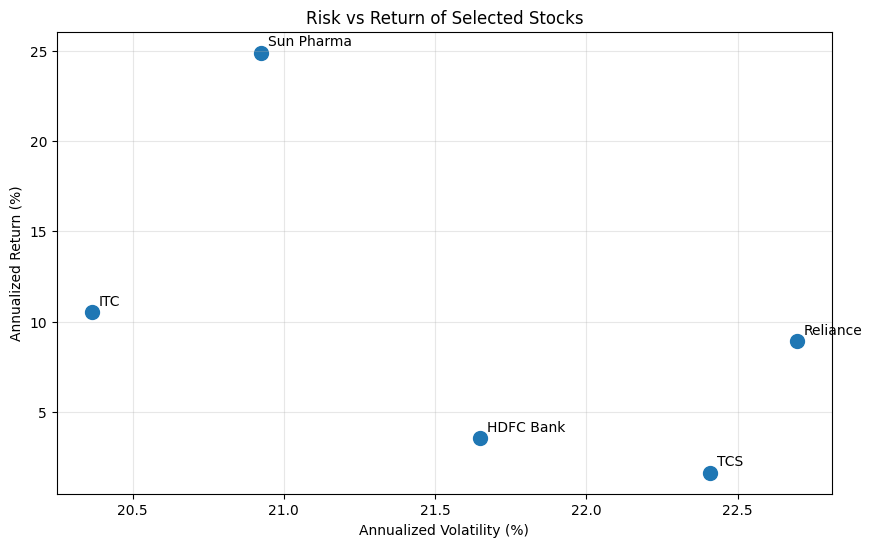

In [79]:
plt.figure(figsize=(10, 6))

plt.scatter(
    annualized_volatility * 100,
    annualized_returns * 100,
    s=100
)

for company in stock_summary.index:
    plt.annotate(
        company,
        (
            annualized_volatility[company] * 100,
            annualized_returns[company] * 100
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Risk vs Return of Selected Stocks")
plt.grid(True, alpha=0.3)

plt.show()

Covariance Matrix

In [80]:
covariance_matrix = daily_returns.cov()

covariance_matrix

Ticker,HDFC Bank,ITC,Reliance,Sun Pharma,TCS
Ticker,,,,,
HDFC Bank,0.000186,0.000041,0.000072,0.000032,0.000043
ITC,0.000041,0.000165,0.000055,0.000032,0.000032
Reliance,0.000072,0.000055,0.000204,0.000043,0.000053
Sun Pharma,0.000032,0.000032,0.000043,0.000174,0.000040
TCS,0.000043,0.000032,0.000053,0.000040,0.000199


In [81]:
annualized_covariance_matrix = covariance_matrix * trading_days

annualized_covariance_matrix

Ticker,HDFC Bank,ITC,Reliance,Sun Pharma,TCS
Ticker,,,,,
HDFC Bank,0.046860,0.010424,0.018250,0.007982,0.010911
ITC,0.010424,0.041479,0.013887,0.007986,0.007954
Reliance,0.018250,0.013887,0.051509,0.010850,0.013445
Sun Pharma,0.007982,0.007986,0.010850,0.043787,0.010139
TCS,0.010911,0.007954,0.013445,0.010139,0.050221


Correlation Matrix

In [82]:
correlation_matrix = daily_returns.corr()

correlation_matrix.round(2)

Ticker,HDFC Bank,ITC,Reliance,Sun Pharma,TCS
Ticker,,,,,
HDFC Bank,1.00,0.24,0.37,0.18,0.22
ITC,0.24,1.00,0.30,0.19,0.17
Reliance,0.37,0.30,1.00,0.23,0.26
Sun Pharma,0.18,0.19,0.23,1.00,0.22
TCS,0.22,0.17,0.26,0.22,1.00


Correlation Heatmap

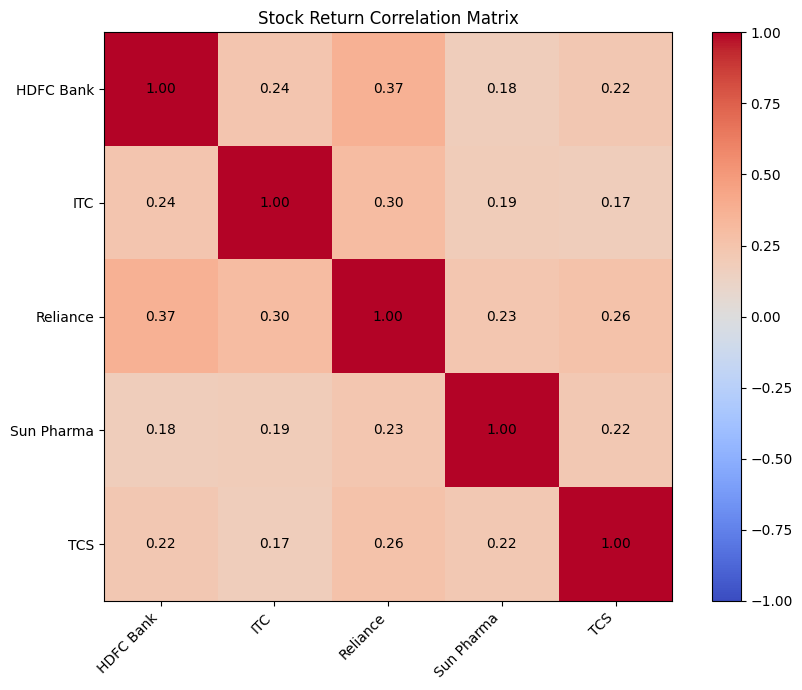

In [83]:
fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.columns)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(image)
plt.title("Stock Return Correlation Matrix")
plt.tight_layout()

plt.show()

Now we actually combine the five stocks

Portfolio Weights


In [84]:
num_assets = len(prices.columns)

weights = np.array([1 / num_assets] * num_assets)

weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [85]:
print("Total Weight:", weights.sum())

Total Weight: 1.0


Portfolio Variance

In [86]:
portfolio_variance = np.dot(
    weights.T,
    np.dot(annualized_covariance_matrix, weights)
)

print("Portfolio Variance:", portfolio_variance)

Portfolio Variance: 0.018300664964132768


Portfolio Volatility

In [87]:
portfolio_volatility = np.sqrt(portfolio_variance)

print(
    "Annual Portfolio Volatility:",
    round(portfolio_volatility * 100, 2),
    "%"
)

Annual Portfolio Volatility: 13.53 %


Sharpe Ratio

In [88]:
risk_free_rate = 0.06

portfolio_sharpe = (
    portfolio_return - risk_free_rate
) / portfolio_volatility

print("Portfolio Sharpe Ratio:", round(portfolio_sharpe, 2))

Portfolio Sharpe Ratio: 0.29


Equal-Weight Portfolio Summary

In [89]:
portfolio_summary = pd.DataFrame({
    "Metric": [
        "Expected Annual Return",
        "Annual Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        f"{portfolio_return * 100:.2f}%",
        f"{portfolio_volatility * 100:.2f}%",
        f"{portfolio_sharpe:.2f}"
    ]
})

portfolio_summary

,Metric,Value
0,Expected Annual Return,9.90%
1,Annual Volatility,13.53%
2,Sharpe Ratio,0.29


Portfolio Allocation

In [90]:
allocation = pd.DataFrame({
    "Company": prices.columns,
    "Weight (%)": weights * 100
})

allocation

,Company,Weight (%)
0,HDFC Bank,20.0
1,ITC,20.0
2,Reliance,20.0
3,Sun Pharma,20.0
4,TCS,20.0


Portfolio Allocation Chart

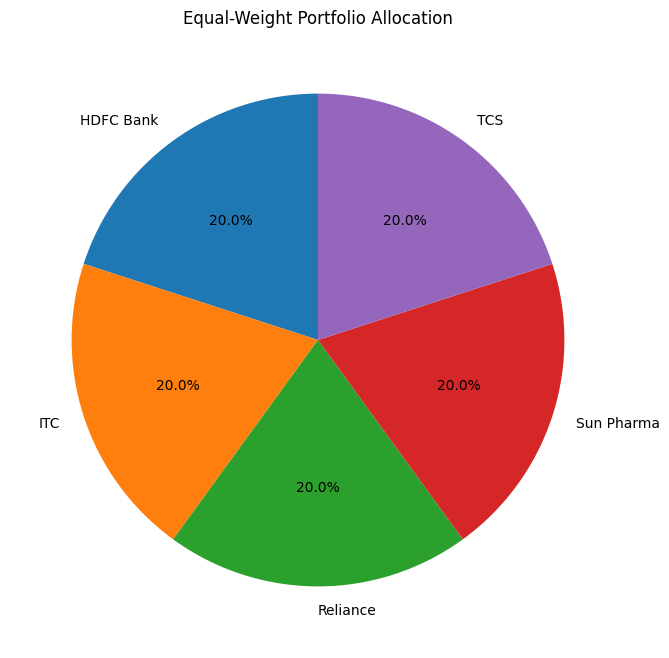

In [91]:
plt.figure(figsize=(8, 8))

plt.pie(
    allocation["Weight (%)"],
    labels=allocation["Company"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Equal-Weight Portfolio Allocation")
plt.show()

Random Portfolio Simulation

In [92]:
num_portfolios = 5000

portfolio_returns = []
portfolio_volatilities = []
portfolio_sharpes = []
portfolio_weights = []

np.random.seed(42)

for i in range(num_portfolios):

    random_weights = np.random.random(num_assets)

    random_weights = random_weights / np.sum(random_weights)

    expected_return = np.dot(
        random_weights,
        annualized_returns
    )

    variance = np.dot(
        random_weights.T,
        np.dot(
            annualized_covariance_matrix,
            random_weights
        )
    )

    volatility = np.sqrt(variance)

    sharpe_ratio = (
        expected_return - risk_free_rate
    ) / volatility

    portfolio_returns.append(expected_return)

    portfolio_volatilities.append(volatility)

    portfolio_sharpes.append(sharpe_ratio)

    portfolio_weights.append(random_weights)

Creating Portfolio Results DataFrame

In [93]:
portfolio_results = pd.DataFrame({
    "Return": portfolio_returns,
    "Volatility": portfolio_volatilities,
    "Sharpe Ratio": portfolio_sharpes
})

portfolio_results.head()

,Return,Volatility,Sharpe Ratio
0,0.117375,0.140515,0.408318
1,0.104622,0.150306,0.296871
2,0.105006,0.154128,0.292007
3,0.113807,0.139546,0.385583
4,0.086222,0.141077,0.185868


In [94]:
portfolio_results.shape

(5000, 3)

Add Portfolio Weights

In [95]:
weights_df = pd.DataFrame(
    portfolio_weights,
    columns=prices.columns
)

portfolio_results = pd.concat(
    [portfolio_results, weights_df],
    axis=1
)

portfolio_results.head()

,Return,Volatility,Sharpe Ratio,HDFC Bank,ITC,Reliance,Sun Pharma,TCS
0,0.117375,0.140515,0.408318,0.133197,0.338101,0.260318,0.212900,0.055485
1,0.104622,0.150306,0.296871,0.065285,0.024308,0.362501,0.251571,0.296334
2,0.105006,0.154128,0.292007,0.009284,0.437468,0.375464,0.095773,0.082010
3,0.113807,0.139546,0.385583,0.105673,0.175297,0.302353,0.248877,0.167800
4,0.086222,0.141077,0.185868,0.327909,0.074759,0.156568,0.196343,0.244421


Finding Best Portfolio

In [96]:
max_sharpe_index = portfolio_results["Sharpe Ratio"].idxmax()

max_sharpe_portfolio = portfolio_results.loc[max_sharpe_index]

max_sharpe_portfolio

,4786
Return,0.187124
Volatility,0.157134
Sharpe Ratio,0.809017
HDFC Bank,0.069588
ITC,0.234719
Reliance,0.036679
Sun Pharma,0.627469
TCS,0.031546


In [97]:
max_sharpe_index = portfolio_results["Sharpe Ratio"].idxmax()

max_sharpe_portfolio = portfolio_results.loc[max_sharpe_index]

max_sharpe_portfolio

,4786
Return,0.187124
Volatility,0.157134
Sharpe Ratio,0.809017
HDFC Bank,0.069588
ITC,0.234719
Reliance,0.036679
Sun Pharma,0.627469
TCS,0.031546


Displaying Best Portfolio

In [98]:
print("MINIMUM VOLATILITY PORTFOLIO")
print("--------------------------------")

print(
    "Expected Annual Return:",
    round(min_volatility_portfolio["Return"] * 100, 2),
    "%"
)

print(
    "Annual Volatility:",
    round(min_volatility_portfolio["Volatility"] * 100, 2),
    "%"
)

print(
    "Sharpe Ratio:",
    round(min_volatility_portfolio["Sharpe Ratio"], 2)
)

print("\nPortfolio Allocation:")

for company in prices.columns:

    print(
        company,
        ":",
        round(min_volatility_portfolio[company] * 100, 2),
        "%"
    )

MINIMUM VOLATILITY PORTFOLIO
--------------------------------
Expected Annual Return: 10.8 %
Annual Volatility: 13.33 %
Sharpe Ratio: 0.36

Portfolio Allocation:
HDFC Bank : 17.91 %
ITC : 24.49 %
Reliance : 12.12 %
Sun Pharma : 24.81 %
TCS : 20.66 %


Minimum-Volatility Portfolio

In [99]:
min_volatility_index = portfolio_results["Volatility"].idxmin()

min_volatility_portfolio = portfolio_results.loc[min_volatility_index]

min_volatility_portfolio

,1525
Return,0.107996
Volatility,0.133337
Sharpe Ratio,0.359959
HDFC Bank,0.179103
ITC,0.244919
Reliance,0.121246
Sun Pharma,0.248082
TCS,0.206649


Display Minimum-Volatility Portfolio

In [100]:
print("MINIMUM VOLATILITY PORTFOLIO")
print("--------------------------------")

print(
    "Expected Annual Return:",
    round(min_volatility_portfolio["Return"] * 100, 2),
    "%"
)

print(
    "Annual Volatility:",
    round(min_volatility_portfolio["Volatility"] * 100, 2),
    "%"
)

print(
    "Sharpe Ratio:",
    round(min_volatility_portfolio["Sharpe Ratio"], 2)
)

print("\nPortfolio Allocation:")

for company in prices.columns:

    print(
        company,
        ":",
        round(min_volatility_portfolio[company] * 100, 2),
        "%"
    )

MINIMUM VOLATILITY PORTFOLIO
--------------------------------
Expected Annual Return: 10.8 %
Annual Volatility: 13.33 %
Sharpe Ratio: 0.36

Portfolio Allocation:
HDFC Bank : 17.91 %
ITC : 24.49 %
Reliance : 12.12 %
Sun Pharma : 24.81 %
TCS : 20.66 %


Portfolio Risk-Return Visualization

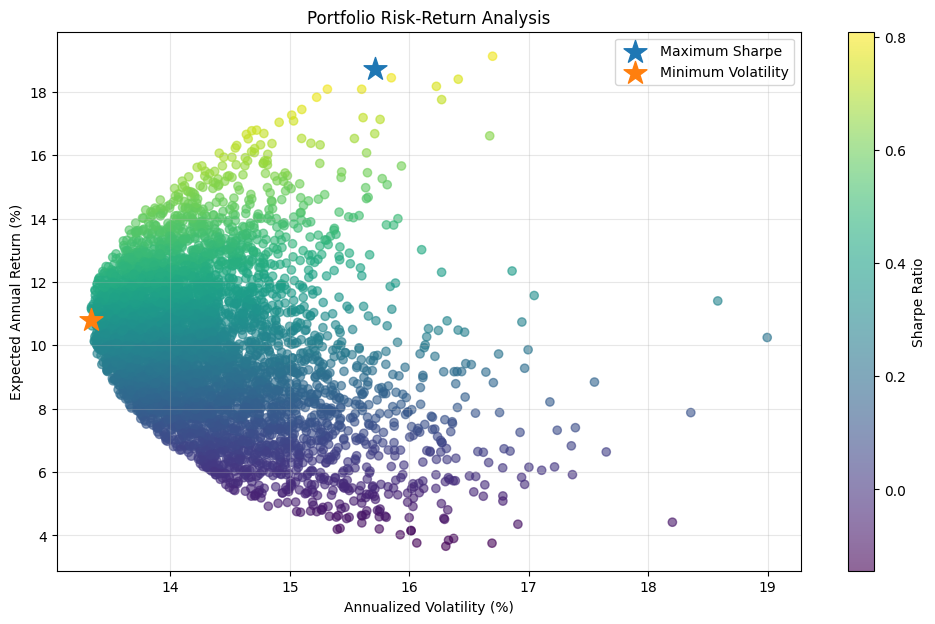

In [101]:
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    portfolio_results["Volatility"] * 100,
    portfolio_results["Return"] * 100,
    c=portfolio_results["Sharpe Ratio"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Sharpe Ratio")

plt.scatter(
    max_sharpe_portfolio["Volatility"] * 100,
    max_sharpe_portfolio["Return"] * 100,
    marker="*",
    s=300,
    label="Maximum Sharpe"
)

plt.scatter(
    min_volatility_portfolio["Volatility"] * 100,
    min_volatility_portfolio["Return"] * 100,
    marker="*",
    s=300,
    label="Minimum Volatility"
)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Expected Annual Return (%)")

plt.title("Portfolio Risk-Return Analysis")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Comparing the Three Portfolios

In [102]:
comparison = pd.DataFrame({
    "Portfolio": [
        "Equal Weight",
        "Maximum Sharpe",
        "Minimum Volatility"
    ],

    "Expected Return (%)": [
        portfolio_return * 100,
        max_sharpe_portfolio["Return"] * 100,
        min_volatility_portfolio["Return"] * 100
    ],

    "Volatility (%)": [
        portfolio_volatility * 100,
        max_sharpe_portfolio["Volatility"] * 100,
        min_volatility_portfolio["Volatility"] * 100
    ],

    "Sharpe Ratio": [
        portfolio_sharpe,
        max_sharpe_portfolio["Sharpe Ratio"],
        min_volatility_portfolio["Sharpe Ratio"]
    ]
})

comparison.round(2)

,Portfolio,Expected Return (%),Volatility (%),Sharpe Ratio
0,Equal Weight,9.90,13.53,0.29
1,Maximum Sharpe,18.71,15.71,0.81
2,Minimum Volatility,10.80,13.33,0.36


Best Portfolio Allocation Chart


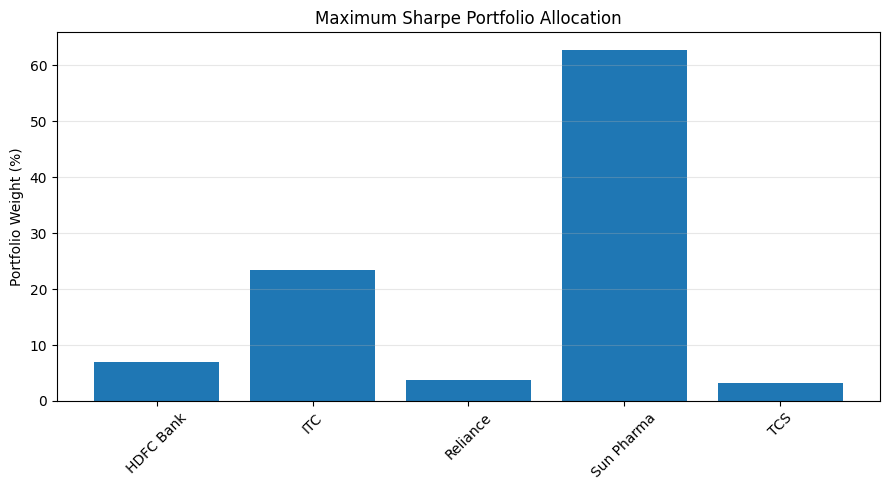

In [103]:
best_weights = max_sharpe_portfolio[prices.columns] * 100

plt.figure(figsize=(9, 5))

plt.bar(
    best_weights.index,
    best_weights.values
)

plt.ylabel("Portfolio Weight (%)")
plt.title("Maximum Sharpe Portfolio Allocation")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

Cumulative Portfolio Performance

Calculating daily equal-weight portfolio returns :

In [104]:
equal_weight_daily_returns = daily_returns.dot(weights)

equal_weight_daily_returns.head()

,0
Date,
2021-01-04,0.008975
2021-01-05,0.000407
2021-01-06,-0.013929
2021-01-07,-0.005810
2021-01-08,0.015342


Converting those returns into cumulative growth.

In [105]:
cumulative_portfolio = (
    1 + equal_weight_daily_returns
).cumprod()

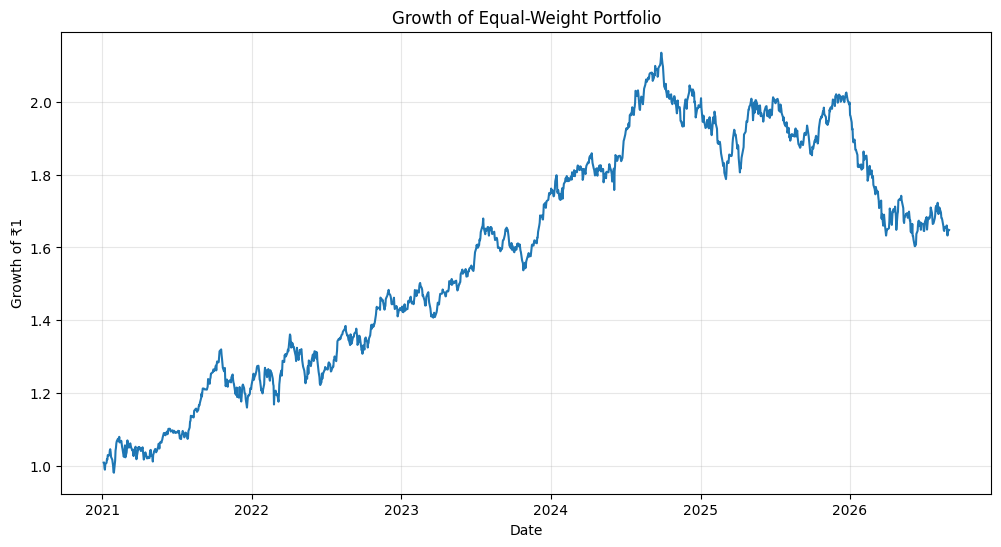

In [106]:
plt.figure(figsize=(12, 6))

plt.plot(
    cumulative_portfolio.index,
    cumulative_portfolio.values
)

plt.title("Growth of Equal-Weight Portfolio")

plt.xlabel("Date")
plt.ylabel("Growth of ₹1")

plt.grid(True, alpha=0.3)

plt.show()

Maximum Sharpe Portfolio Historical Growth

In [107]:
max_sharpe_weights = max_sharpe_portfolio[
    prices.columns
].values.astype(float)

max_sharpe_daily_returns = daily_returns.dot(
    max_sharpe_weights
)

max_sharpe_cumulative = (
    1 + max_sharpe_daily_returns
).cumprod()

Comparing Historical Growth

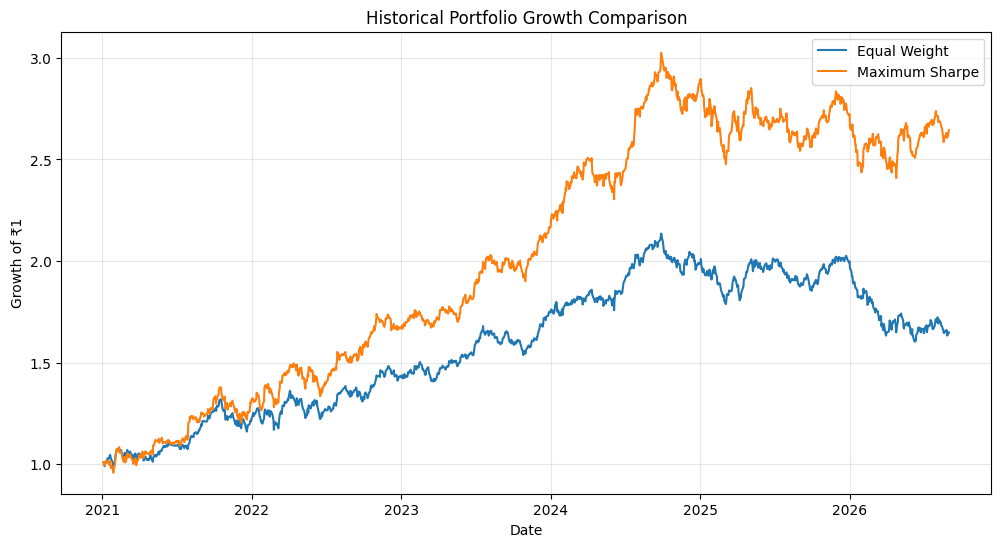

In [108]:
plt.figure(figsize=(12, 6))

plt.plot(
    cumulative_portfolio.index,
    cumulative_portfolio,
    label="Equal Weight"
)

plt.plot(
    max_sharpe_cumulative.index,
    max_sharpe_cumulative,
    label="Maximum Sharpe"
)

plt.title("Historical Portfolio Growth Comparison")

plt.xlabel("Date")
plt.ylabel("Growth of ₹1")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

Final Results Table

In [109]:
final_results = stock_summary.copy()

final_results["Annualized Return (%)"] = (
    annualized_returns * 100
).round(2)

final_results["Annualized Volatility (%)"] = (
    annualized_volatility * 100
).round(2)

final_results

,Annualized Return (%),Annualized Volatility (%)
Ticker,,
HDFC Bank,3.52,21.65
ITC,10.52,20.37
Reliance,8.92,22.70
Sun Pharma,24.89,20.93
TCS,1.62,22.41


Saving Results

In [110]:
final_results.to_csv(
    "stock_risk_return_summary.csv"
)

correlation_matrix.to_csv(
    "stock_correlation_matrix.csv"
)

portfolio_results.to_csv(
    "simulated_portfolios.csv",
    index=False
)

comparison.to_csv(
    "portfolio_comparison.csv",
    index=False
)

print("Files saved successfully.")

Files saved successfully.
